In [33]:
# setup
import sys
import os

sys.path.append(os.path.abspath(".."))

# ICVul
import pandas as pd

df_vuln = pd.read_csv('../data/intermediate/churn_icvul.csv')

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
print(f"Total commits: {len(df_vuln)}")
# df_vuln.groupby('commit_role')[metrics].agg(['median', 'mean', 'count']).round(2)

import json

with open('../data/raw/tool_assisted_manual_dataset.json', 'r') as f:
    tosem = json.load(f)

total_vfc = len(set(commit for entry in tosem for commit in entry['fixing']))
total_vic = len(set(entry['introducing'] for entry in tosem if entry.get('introducing')))
total_cves = len(set(entry['cve'] for entry in tosem))
total_projects = len(set(entry['repository'] for entry in tosem))

print(f"Total unique VFCs: {total_vfc}")
print(f"Total unique VICs: {total_vic}")
print(f"Total unique CVEs: {total_cves}")
print(f"Total unique projects: {total_projects}")

Total commits: 13003
Total unique VFCs: 187
Total unique VICs: 95
Total unique CVEs: 100
Total unique projects: 71


In [34]:
# KFC (Linux)
import pandas as pd

df_bug = pd.read_csv('../data/intermediate/churn_linux.csv')

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

In [35]:
# TOSEM
import pandas as pd

df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem.csv')

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

In [36]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache.csv')

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

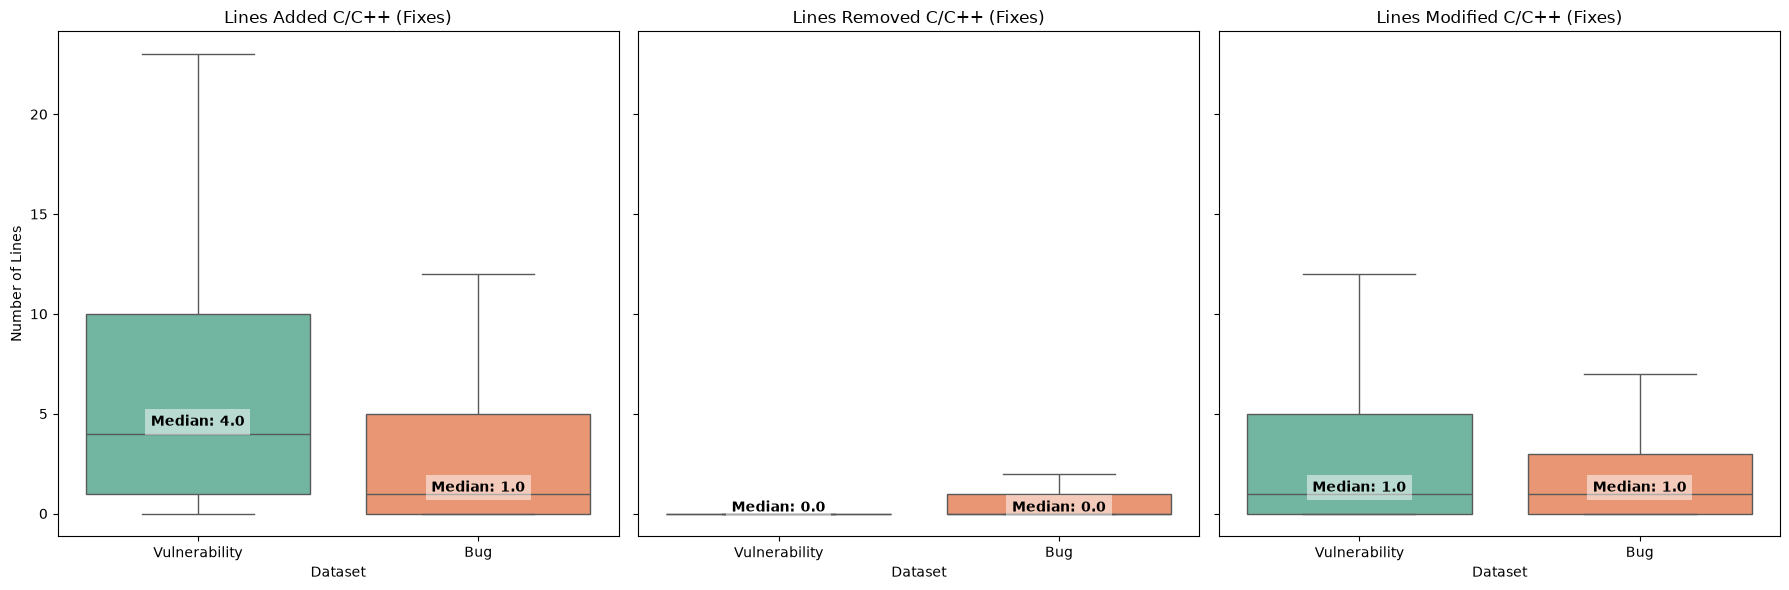


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 2.71e-196    |   0.266 (small     ) | *
Lines Removed      | 9.77e-13     |  -0.051 (negligible) | *
Lines Modified     | 5.87e-17     |   0.075 (negligible) | *


          Lines Added          Lines Removed          Lines Modified         
Dataset Vulnerability      Bug Vulnerability      Bug  Vulnerability      Bug
n              4230.0  63896.0        4230.0  63896.0         4230.0  63896.0
Median            4.0      1.0           0.0      0.0            1.0      1.0
Q1                1.0      0.0           0.0      0.0            0.0      0.0
Q3               10.0      5.0           0.0      1.0            5.0      3.0
Minimum           0.0      0.0           0.0      0.0            0.0      0.0
Maximum         986.0   1163.0       

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Fixes)', 'Lines Removed C/C++ (Fixes)', 'Lines Modified C/C++ (Fixes)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

from utils.stats import run_stats, descriptive_stats_table

run_stats(df_fixing)
table = descriptive_stats_table(df_fixing)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

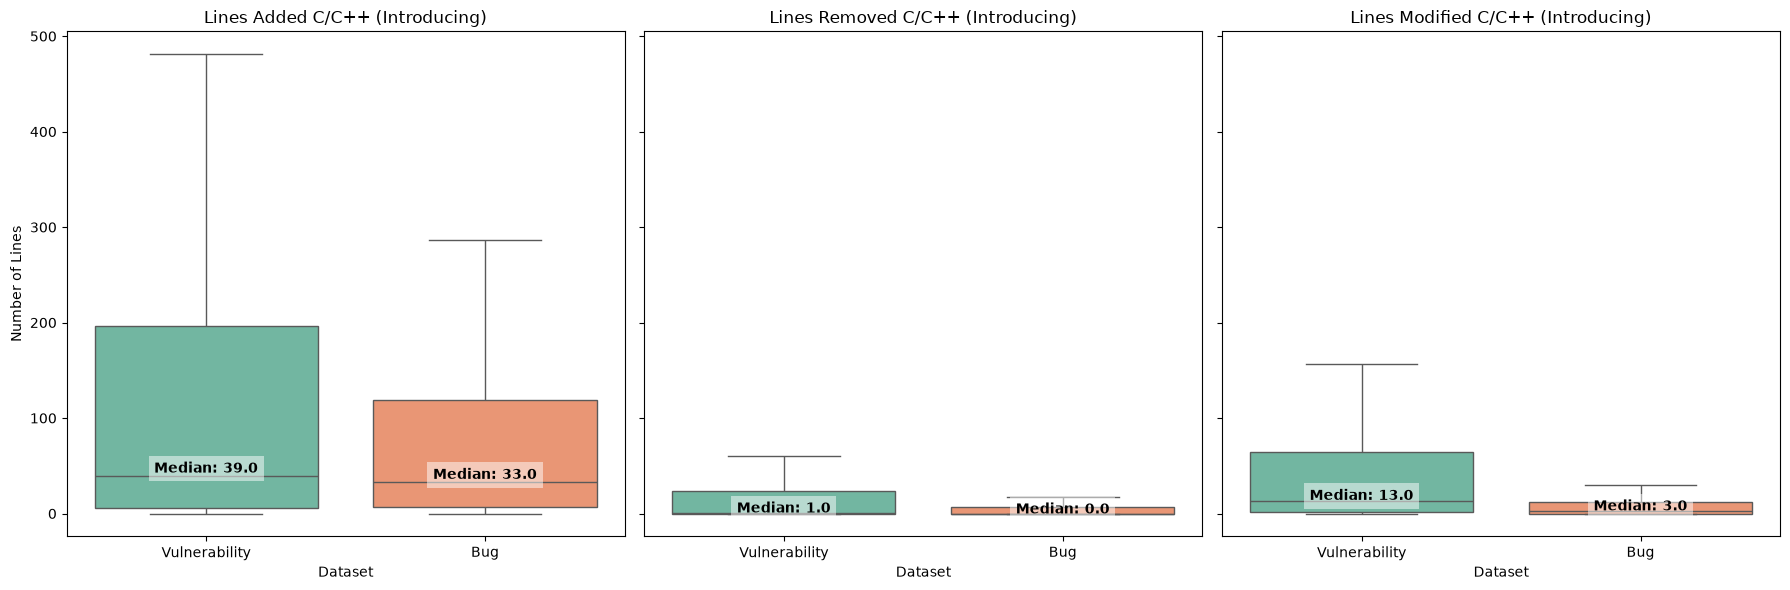


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 8.30e-15     |   0.053 (negligible) | *
Lines Removed      | 3.81e-159    |   0.166 (small     ) | *
Lines Modified     | 0.00e+00     |   0.351 (medium    ) | *


          Lines Added          Lines Removed          Lines Modified         
Dataset Vulnerability      Bug Vulnerability      Bug  Vulnerability      Bug
n              8512.0  48461.0        8512.0  48461.0         8512.0  48461.0
Median           39.0     33.0           1.0      0.0           13.0      3.0
Q1                6.0      7.0           0.0      0.0            2.0      0.0
Q3              196.0    119.0          24.0      7.0           64.0     12.0
Minimum           0.0      0.0           0.0      0.0            0.0      0.0
Maximum        9885.0   9892.0      2

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

df_introducing = pd.concat([
    df_vuln[(df_vuln['commit_role'] == 'VIC') & (df_vuln['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[(df_bug['commit_role'] == 'BIC') & (df_bug['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Introducing)', 'Lines Removed C/C++ (Introducing)', 'Lines Modified C/C++ (Introducing)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_introducing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_introducing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

run_stats(df_introducing)
table = descriptive_stats_table(df_introducing)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

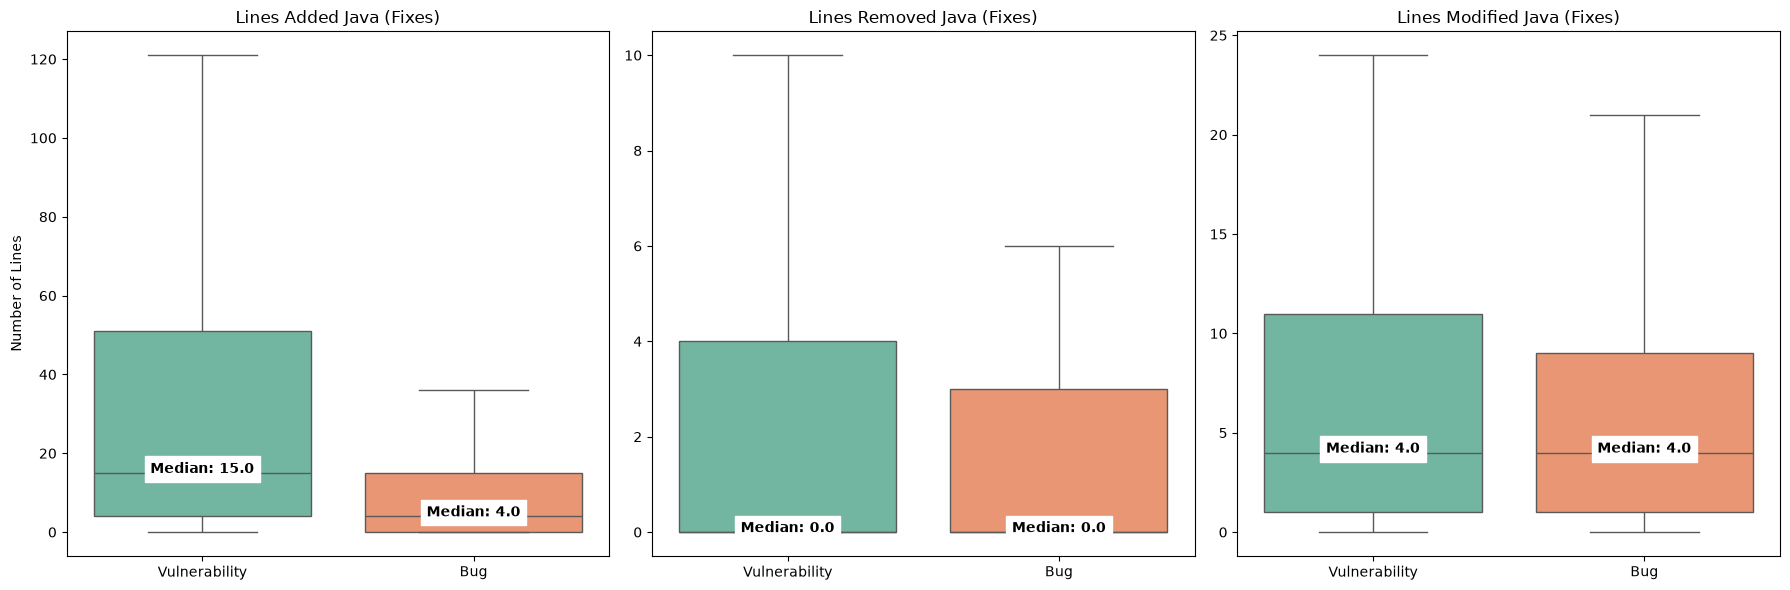


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 3.60e-10     |   0.373 (medium    ) | *
Lines Removed      | 0.35970      |   0.049 (negligible) | 
Lines Modified     | 0.99311      |  -0.001 (negligible) | 


          Lines Added        Lines Removed        Lines Modified       
Dataset Vulnerability    Bug Vulnerability    Bug  Vulnerability    Bug
n               177.0  198.0         177.0  198.0          177.0  198.0
Median           15.0    4.0           0.0    0.0            4.0    4.0
Q1                4.0    0.0           0.0    0.0            1.0    1.0
Q3               51.0   15.0           4.0    3.0           11.0    9.0
Minimum           0.0    0.0           0.0    0.0            0.0    0.0
Maximum        1688.0  807.0        1631.0  523.0          199.0  294.0


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Fixes)', 'Lines Removed Java (Fixes)', 'Lines Modified Java (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp)
table = descriptive_stats_table(df_java_comp)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

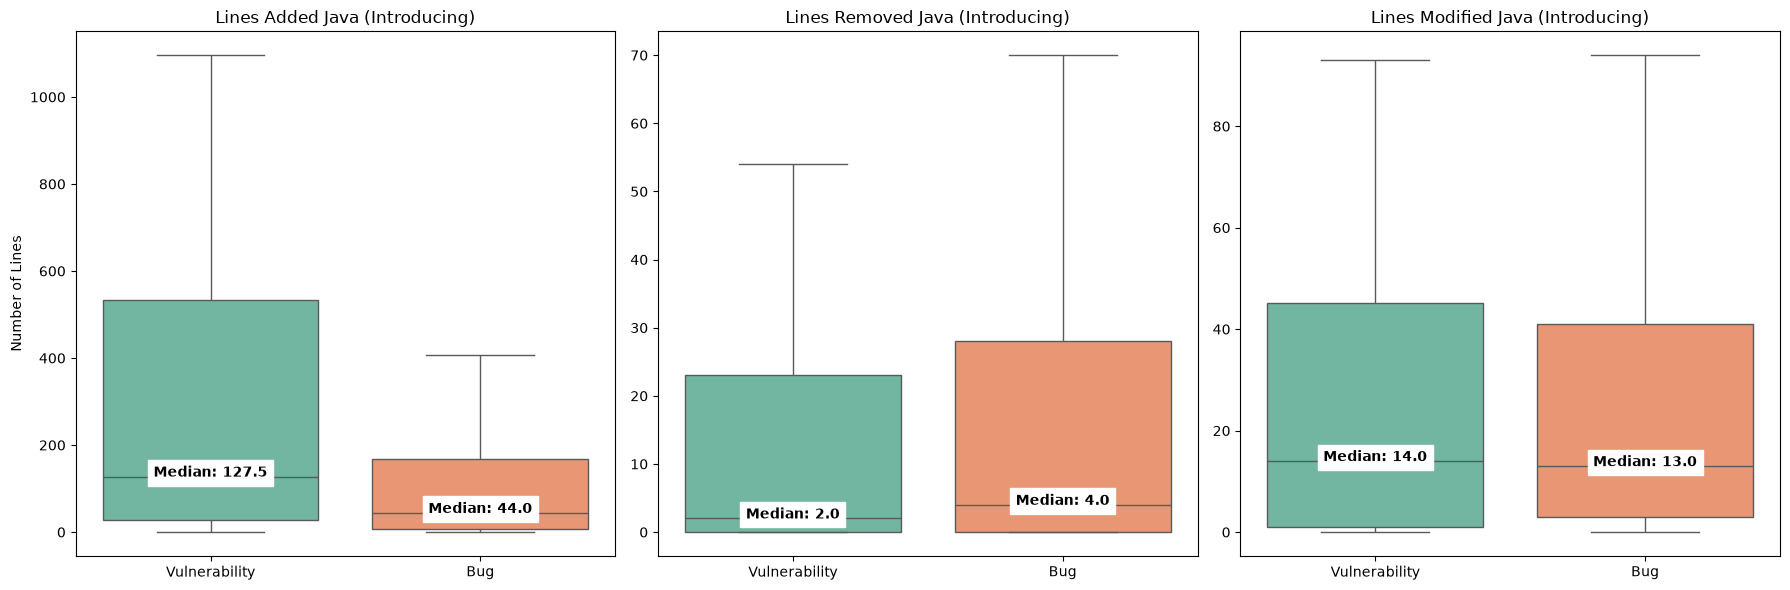


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 2.89e-05     |   0.300 (small     ) | *
Lines Removed      | 0.51409      |  -0.045 (negligible) | 
Lines Modified     | 0.32216      |  -0.071 (negligible) | 


          Lines Added         Lines Removed         Lines Modified        
Dataset Vulnerability     Bug Vulnerability     Bug  Vulnerability     Bug
n                84.0   285.0          84.0   285.0           84.0   285.0
Median          127.5    44.0           2.0     4.0           14.0    13.0
Q1               28.0     8.0           0.0     0.0            1.0     3.0
Q3              532.5   168.0          23.0    28.0           45.2    41.0
Minimum           0.0     0.0           0.0     0.0            0.0     0.0
Maximum        9075.0  7090.0       55243.0  2562.0         

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixses
df_v = df_java_vic_only.copy()
df_v = df_v[df_v['lines_added'] < 10000]
df_b = df_java_bic_only.copy()
df_b = df_b[df_b['lines_added'] < 10000] # this dataset doesn't have any commits with > 10k

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp_i = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Introducing)', 'Lines Removed Java (Introducing)', 'Lines Modified Java (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp_i, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp_i.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp_i)
table = descriptive_stats_table(df_java_comp_i)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)